In [1]:
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import sys

sys.path.append("/scratch/nar8991/snn/snn_ann_hybrid")

from class_based_implementation.models import SNN, ANN_with_LIF_output, Hybrid_RNN_SNN_rec, Hybrid_RNN_SNN_V1_same_layer, NSN_with_LIF_output, Hybrid_NSN_SNN_rec, Hybrid_NSN_SNN_V1_same_layer
from class_based_implementation.surr_grad import SurrGradSpike

from maren_data.helpers import choose_data_params

# Import the randman stuff from DarwinNeuron instead
sys.path.append("/scratch/nar8991/snn/DarwinNeuron")
from src.RandmanFunctions import RandmanConfig, split_and_load, split_test_and_load
import os

def compute_sam_sharpness(model, dataloader, rho=0.05, device='cuda'):
    """
    Computes the SAM loss at the trained model weights (the minimum),
    giving a scalar sharpness measure.
    """
    model.to(device)
    model.zero_grad()
    criterion = nn.CrossEntropyLoss()
    # 1. Compute vanilla gradients 
    total_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions, _, _, _ = model(inputs)
        logit_output, _ = torch.max(predictions, dim=1)
        loss = criterion(logit_output, targets)
        loss.backward()
        total_loss += loss.item()

    # 2. Flatten gradients
    grad = torch.cat([p.grad.flatten().to(device) for p in model.parameters() if p.grad is not None])
    grad_norm = torch.norm(grad)
    if grad_norm == 0:
        # If gradient is zero, sharpness is zero
        return 0.0, 0.0

    # Add this normalization step
    normalized_grad = grad / grad_norm

    # 3. Perturb weights in the gradient direction (SAM)
    offset = 0
    with torch.no_grad():
        for p in model.parameters():
            if p.grad is None:
                continue
            numel = p.numel()
            epsilon = rho * normalized_grad[offset:offset+numel].view_as(p)
            p.add_(epsilon)
            offset += numel

    # 4. Evaluate loss at the perturbed weights
    sam_total_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions, _, _, _ = model(inputs)
        logit_output, _ = torch.max(predictions, dim=1)
        sam_loss = criterion(logit_output, targets)
        sam_total_loss += sam_loss.item()
    avg_sam = sam_total_loss / len(dataloader)
    diff_sam = (sam_total_loss - total_loss) / len(dataloader) # Shifted the order!
    # 6. Return average SAM loss across the dataset
    return avg_sam, diff_sam


/scratch/nar8991/snn/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
def get_randman_data():
    data_loader_config = {
        'randman_id': 0,
        'randman_dir': '/scratch/nar8991/snn/DarwinNeuron/data/randman' # We could set this to datapath but this is probably easiest
    }
    batch_size=516

    randman = RandmanConfig.lookup_by_id(data_loader_config['randman_id'], os.path.join(data_loader_config['randman_dir'], "meta-data.csv"))
    dataset = randman.read_dataset(data_loader_config['randman_dir'])
    train_loader, _ = split_and_load(dataset, batch_size=batch_size)
    return train_loader
def get_shd_train_data():
    pre_path_data = f"/scratch/nar8991/snn/snn_ann_hybrid/maren_data/shd/700_inputs/1.0_max_time/False_noise"
    settings = {}
    settings["max_time"] = 1
    settings["noise"] = False
    settings["time_step"] = 0.002
    settings["nb_inputs"] = 700
    settings["nb_outputs"] = 20
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    settings["device"] = device
    settings["dtype"] = torch.float32
    settings["batch_size"] = 256
    settings["percent_data"] = 1.0  # Use all data

    train_loader, _, _ = choose_data_params(
        "shd", settings, num_workers=0, pre_path=pre_path_data
        )
    return train_loader    

In [3]:
MODEL_CLASSES = {
    "NSN_with_LIF_output": NSN_with_LIF_output,
    "SNN": SNN,
    "ANN_with_LIF_output": ANN_with_LIF_output,
    "Hybrid_RNN_SNN_rec": Hybrid_RNN_SNN_rec,
    "Hybrid_NSN_SNN_rec": Hybrid_NSN_SNN_rec,
    "Hybrid_RNN_SNN_V1_same_layer": Hybrid_RNN_SNN_V1_same_layer,
    "Hybrid_NSN_SNN_V1_same_layer": Hybrid_NSN_SNN_V1_same_layer,
}

from test_visualizations.utils import get_randman_test_data, get_shd_test_data, compute_accuracy


def calculate_and_visualize_sam(data, models_selected=None, sampler_type="grid", base_prefix="vast"):
    if data == 'randman':
        BASE_PATH=f"/{base_prefix}/nar8991/snn/training_results/randman/1_d/2_classes/3/cross_entropy"
        train_loader = get_randman_data()
        test_loader = get_randman_test_data()
        hidden_neurons = 20
    elif data == 'shd':
        BASE_PATH=f"/{base_prefix}/nar8991/snn/snn_ann_hybrid/training_results/shd/None_d/20_classes/700/cross_entropy"
        train_loader = get_shd_train_data()
        test_loader = get_shd_test_data()
        hidden_neurons = 256
    rho_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

    # Adjusted structure to store avg and diff SAM values separately for each rho
    sam_results = {
        'avg': {rho: [] for rho in rho_list},
        'diff': {rho: [] for rho in rho_list},
        'test_acc': {rho: [] for rho in rho_list},  # Store test accuracies for each rho
        'train_acc': {rho: [] for rho in rho_list},  # Store train
    }
    labels = []

    if models_selected is not None:
        new_model_classes = {k: v for k, v in MODEL_CLASSES.items() if k in models_selected}
    else:
        new_model_classes = MODEL_CLASSES

    for model_name, model_class in new_model_classes.items():
        for recurrent in ["True"]:
            percent_list = [0.25, 0.5, 0.75] if 'Hybrid' in model_name else [None]
            for percent in percent_list:
                # if percent is not None:
                label = f"{model_name} | recurrent={recurrent} | {percent}_percent_snn"
                model_path_suffix = f"{percent}_percent_snn/best_model_of_study.ckpt"
                # else:
                #     label = f"{model_name} | recurrent={recurrent}"
                #     model_path_suffix = "best_model_of_study.ckpt"
                labels.append(label)
                for rho in rho_list: # Only process these rhos, others will remain empty as per original code
                    avg_sam_vals = []
                    diff_sam_vals = []
                    seeds = range(1, 5)
                    for seed in tqdm(seeds, desc=f"{label} rho={rho}"):
                        base_path = f"{BASE_PATH}/{model_name}/recurrent_{recurrent}/seed_{seed}/{sampler_type}_sampler/{hidden_neurons}_hidden/1.0_pct_data"
                        model_file_path = f"{base_path}/{model_path_suffix}"
                        # Ensure the model_class can be instantiated or loaded correctly here.
                        # For now, using the dummy load_from_checkpoint.
                        model = model_class.load_from_checkpoint(model_file_path, strict=False)
                        # WE SHOULD PROBABLY STREAMLINE THIS
                        test_accuracy = compute_accuracy(model, test_loader)
                        train_accuracy = compute_accuracy(model, train_loader)
                        avg_sam, diff_sam = compute_sam_sharpness(model, train_loader, rho=rho)
                        avg_sam_vals.append(avg_sam)
                        diff_sam_vals.append(diff_sam)
                    sam_results['avg'][rho].append(avg_sam_vals)
                    sam_results['diff'][rho].append(diff_sam_vals)
                    sam_results['test_acc'][rho].append(test_accuracy) #These will be the same for all rhos for a given model
                    sam_results['train_acc'][rho].append(train_accuracy) 
    return rho_list, sam_results, labels



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Helper function to plot box plots
def plot_sharpness_boxplots(sam_results, rho_list, labels):
    """
    Plots box plots for average and difference SAM sharpness.
    """
    # Plotting for Average SAM Sharpness
    fig_avg, axes_avg = plt.subplots(1, len(rho_list), figsize=(18, 8), sharey=True)
    if len(rho_list) == 1:
        axes_avg = [axes_avg]
    for idx, rho in enumerate(rho_list):
        ax = axes_avg[idx]
        data_to_plot = [sam_results['avg'][rho][model_idx] for model_idx in range(len(labels))]
        ax.boxplot(data_to_plot, vert=False, positions=np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels)
        ax.set_title(f"rho={rho}")
        ax.set_xlabel("Average SAM Sharpness")
        if idx == 0:
            ax.set_ylabel("Model | Recurrent")
    plt.suptitle("Average SAM Sharpness Across Models and Rhos", y=1.02)
    plt.tight_layout()
    plt.show()

    # Plotting for Difference SAM Sharpness
    fig_diff, axes_diff = plt.subplots(1, len(rho_list), figsize=(18, 8), sharey=True)
    if len(rho_list) == 1:
        axes_diff = [axes_diff]
    for idx, rho in enumerate(rho_list):
        ax = axes_diff[idx]
        data_to_plot = [sam_results['diff'][rho][model_idx] for model_idx in range(len(labels))]
        ax.boxplot(data_to_plot, vert=False, positions=np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels)
        ax.set_title(f"rho={rho}")
        ax.set_xlabel("Difference SAM Sharpness")
        if idx == 0:
            ax.set_ylabel("Model | Recurrent")
    plt.suptitle("Difference SAM Sharpness Across Models and Rhos", y=1.02)
    plt.tight_layout()
    plt.show()

# Helper function to calculate and plot similarity matrices for a single rho
def plot_single_rho_similarity(sam_results, rho, labels):
    """
    Calculates and plots Euclidean and Cosine similarity matrices for a single rho value.
    """
    if len(labels) <= 1:
        print(f"Not enough models to create similarity matrices for rho={rho}.")
        return

    # Create sharpness profiles for the current rho, based only on difference SAM
    current_rho_diff_profiles = np.array([
        [np.mean(sam_results['diff'][rho][model_idx])]
        for model_idx in range(len(labels))
    ])

    # Euclidean Distance-based Similarity Matrix
    distances = pdist(current_rho_diff_profiles, metric='euclidean')
    distance_matrix = squareform(distances)
    max_dist = np.max(distance_matrix)
    euclidean_similarity_matrix = 1 - (distance_matrix / max_dist) if max_dist > 0 else np.ones_like(distance_matrix)

    plt.figure(figsize=(12, 10))
    sns.heatmap(euclidean_similarity_matrix, annot=True, cmap='viridis', fmt=".2f",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Euclidean Similarity (1 = most similar)'})
    plt.title(f"Model Sharpness Euclidean Similarity Matrix (Difference SAM for rho={rho})")
    plt.tight_layout()
    plt.show()

    # Cosine Similarity Matrix
    if not np.all(current_rho_diff_profiles == 0):
        cosine_sim_matrix = cosine_similarity(current_rho_diff_profiles)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cosine_sim_matrix, annot=True, cmap='viridis', fmt=".2f",
                    xticklabels=labels, yticklabels=labels,
                    cbar_kws={'label': 'Cosine Similarity (1 = most similar, -1 = most dissimilar)'})
        plt.title(f"Model Sharpness Cosine Similarity Matrix (Difference SAM for rho={rho})")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping Cosine Similarity Matrix for rho={rho} due to all-zero profiles.")

# Helper function to calculate and plot overall similarity matrices across all rhos
def plot_overall_similarity(sam_results, rho_list, labels):
    """
    Calculates and plots overall Euclidean and Cosine similarity matrices across all rhos.
    """
    if len(labels) <= 1:
        print("Not enough models to create overall similarity matrices.")
        return

    model_profiles_across_rhos = np.array([
        [np.mean(sam_results['diff'][rho][model_idx]) for rho in rho_list]
        for model_idx in range(len(labels))
    ])

    # Euclidean Distance-based Overall Similarity Matrix
    distances_overall = pdist(model_profiles_across_rhos, metric='euclidean')
    distance_matrix_overall = squareform(distances_overall)
    max_dist_overall = np.max(distance_matrix_overall)
    euclidean_similarity_matrix_overall = 1 - (distance_matrix_overall / max_dist_overall) if max_dist_overall > 0 else np.ones_like(distance_matrix_overall)

    plt.figure(figsize=(12, 10))
    sns.heatmap(euclidean_similarity_matrix_overall, annot=True, cmap='viridis', fmt=".2f",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Euclidean Similarity (1 = most similar)'})
    plt.title("Overall Model Sharpness Euclidean Similarity Matrix (Difference SAM across all Rhos)")
    plt.tight_layout()
    plt.show()

    # Cosine Similarity Overall Matrix
    if not np.all(model_profiles_across_rhos == 0):
        cosine_sim_matrix_overall = cosine_similarity(model_profiles_across_rhos)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cosine_sim_matrix_overall, annot=True, cmap='viridis', fmt=".2f",
                    xticklabels=labels, yticklabels=labels,
                    cbar_kws={'label': 'Cosine Similarity (1 = most similar, -1 = most dissimilar)'})
        plt.title("Overall Model Sharpness Cosine Similarity Matrix (Difference SAM across all Rhos)")
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping Overall Cosine Similarity Matrix due to all-zero profiles across rhos.")

# Helper function for PCA visualization
def plot_pca_visualization(sam_results, rho_list, labels):
    """
    Performs and visualizes PCA on the model sharpness profiles.
    Each individual data point for PCA is a single seed's sharpness profile
    (its difference SAM values across all rhos).
    This allows for multiple points per model configuration label.
    """
    if len(labels) <= 1:
        print("Not enough models to perform PCA visualization.")
        return

    pca_input_data = []
    corresponding_labels = []

    # First, determine the number of seeds present in the data for the first model/rho
    # This assumes a consistent number of seeds for all valid model/rho combinations.
    num_seeds = 0
    if rho_list and sam_results['diff'].get(rho_list[0]) and sam_results['diff'][rho_list[0]][0]:
        num_seeds = len(sam_results['diff'][rho_list[0]][0])

    if num_seeds == 0:
        print("No seed data found or inconsistent data structure. Cannot perform PCA with multiple points per label.")
        return

    # Loop through each unique model configuration (represented by 'labels')
    for model_idx, label in enumerate(labels):
        # For each model, gather the sharpness profiles for each seed
        for seed_idx in range(num_seeds):
            seed_profile = []
            is_seed_profile_valid = True
            for rho in rho_list:
                # Check if data exists for this specific rho, model, and seed
                if rho in sam_results['diff'] and model_idx < len(sam_results['diff'][rho]) \
                   and seed_idx < len(sam_results['diff'][rho][model_idx]):
                    seed_profile.append(sam_results['diff'][rho][model_idx][seed_idx])
                else:
                    # If any part of the profile is missing, this seed's profile is incomplete.
                    # We can choose to skip it or fill with a default value (e.g., 0).
                    # For PCA, it's generally better to have complete vectors.
                    # Let's fill with 0 for missing values, assuming it represents no sharpness.
                    seed_profile.append(0.0) 
            
            # Only add the profile if it's not entirely zeros (indicating actual data)
            # This handles cases where a model/seed combination might genuinely have all zero sharpness
            # or if it was partially missing and filled with zeros.
            if any(val != 0 for val in seed_profile): 
                pca_input_data.append(seed_profile)
                corresponding_labels.append(label)

    if not pca_input_data:
        print("No valid data points generated for PCA after filtering. Skipping PCA visualization.")
        return

    pca_input_data = np.array(pca_input_data)

    if pca_input_data.shape[0] < 2:
        print("Not enough samples (less than 2) for PCA visualization after filtering. Skipping PCA.")
        return
    if pca_input_data.shape[1] < 2:
        print(f"Not enough features (dimensions) for PCA (need at least 2, got {pca_input_data.shape[1]}). Skipping PCA.")
        return
    
    # Check if all data points are identical after scaling, which would break PCA
    # Calculate variance for each feature (column)
    feature_variances = np.var(pca_input_data, axis=0)
    # If all feature variances are effectively zero, PCA will fail
    if np.all(np.isclose(feature_variances, 0)):
        print("All data points are identical or have zero variance. PCA not meaningful. Skipping PCA visualization.")
        return

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pca_input_data)
    
    # Determine the number of components to use for PCA
    # min(number of samples - 1, number of features, 2)
    n_components_to_use = min(scaled_data.shape[0] - 1, scaled_data.shape[1], 2)
    
    if n_components_to_use < 2:
        print(f"Not enough dimensions ({n_components_to_use} available) to perform a 2D PCA for visualization. Skipping PCA.")
        return

    pca = PCA(n_components=n_components_to_use)
    principal_components = pca.fit_transform(scaled_data)

    plt.figure(figsize=(14, 10)) # Increased figure size
    unique_labels = sorted(list(set(corresponding_labels)))
    colors = plt.cm.get_cmap('tab20', len(unique_labels)) # Use tab20 for more distinct colors

    for i, label in enumerate(unique_labels):
        # Find indices for the current label in the corresponding_labels list
        idx = [j for j, l in enumerate(corresponding_labels) if l == label]
        
        # Plot all points belonging to this label
        plt.scatter(principal_components[idx, 0], principal_components[idx, 1],
                    label=label, color=colors(i % 20), alpha=0.7, s=80, # Use modulo for color cycling
                    edgecolors='w', linewidth=0.5) # Add white edge for better visibility

    plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize=12)
    plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize=12)
    plt.title("PCA of Model Sharpness Profiles (Difference SAM across all Rhos)", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10) # Move legend outside plot
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
    plt.show()

# Main refactored function
def plot_sam_results(rho_list, sam_results, labels):
    """
    Master function to plot SAM results, including sharpness boxplots,
    similarity matrices, and PCA visualization.
    """
    # 1. Plot sharpness distributions using box plots
    plot_sharpness_boxplots(sam_results, rho_list, labels)

    # # 2. Plot similarity matrices for each rho
    # for rho in rho_list:
    #     plot_single_rho_similarity(sam_results, rho, labels)

    # # 3. Plot overall similarity matrices across all rhos
    # plot_overall_similarity(sam_results, rho_list, labels)

    # # 4. Perform and plot PCA
    # plot_pca_visualization(sam_results, rho_list, labels)

In [5]:
import pandas as pd
import glob

csv_dir = "/scratch/nar8991/snn/output/sam_results_csv_final"
csv_files = glob.glob(f"{csv_dir}/*.csv")

# Read and concatenate all CSVs
df_all = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
# Sort by model_name and percent (percent_snn)
df_all = df_all.sort_values(by=["model_name", "percent"]).reset_index(drop=True)

# Assume columns: 'model', 'recurrent', 'percent', 'rho', 'avg_sam', 'diff_sam', 'seed'
rho_list = sorted(df_all['rho'].unique())
labels = []
label_map = {}

for _, row in df_all.iterrows():
    percent_str = f"{row['percent']}_percent_snn" if pd.notnull(row['percent']) else ""
    label = f"{row['model_name']} | recurrent={row['recurrent']}" + (f" | {percent_str}" if percent_str else "")
    if label not in label_map:
        label_map[label] = len(labels)
        labels.append(label)

# Build sam_results dict
sam_results = {
    'avg': {rho: [[] for _ in labels] for rho in rho_list},
    'diff': {rho: [[] for _ in labels] for rho in rho_list}
}

for _, row in df_all.iterrows():
    percent_str = f"{row['percent']}_percent_snn" if pd.notnull(row['percent']) else ""
    label = f"{row['model_name']} | recurrent={row['recurrent']}" + (f" | {percent_str}" if percent_str else "")
    idx = label_map[label]
    rho = row['rho']
    sam_results['avg'][rho][idx].append(row['avg_sam'])
    sam_results['diff'][rho][idx].append(row['diff_sam'])

In [6]:
# # THIS IS SHD
# plot_sam_results(rho_list, sam_results, labels)

In [7]:
# Adjust this so it's V1 only
models = ["SNN", "Hybrid_NSN_SNN_V1_same_layer", "NSN_with_LIF_output"]
rho_list, sam_results, labels = calculate_and_visualize_sam("randman", models_selected=models, sampler_type="tpe", base_prefix="vast")


Testing: 100%|██████████| 3/3 [00:00<00:00, 34.40it/s]
NSN_with_LIF_output | recurrent=True | None_percent_snn rho=0.01: 100%|██████████| 4/4 [00:04<00:00,  1.05s/it]
Testing: 100%|██████████| 3/3 [00:00<00:00, 34.69it/s]
NSN_with_LIF_output | recurrent=True | None_percent_snn rho=0.05: 100%|██████████| 4/4 [00:01<00:00,  2.48it/s]
Testing: 100%|██████████| 3/3 [00:00<00:00, 34.39it/s]
NSN_with_LIF_output | recurrent=True | None_percent_snn rho=0.1: 100%|██████████| 4/4 [00:01<00:00,  2.47it/s]
Testing: 100%|██████████| 3/3 [00:00<00:00, 34.66it/s]
NSN_with_LIF_output | recurrent=True | None_percent_snn rho=0.2: 100%|██████████| 4/4 [00:01<00:00,  2.48it/s]
Testing: 100%|██████████| 3/3 [00:00<00:00, 34.31it/s]
NSN_with_LIF_output | recurrent=True | None_percent_snn rho=0.3: 100%|██████████| 4/4 [00:01<00:00,  2.49it/s]
Testing: 100%|██████████| 3/3 [00:00<00:00, 34.30it/s]
NSN_with_LIF_output | recurrent=True | None_percent_snn rho=0.4: 100%|██████████| 4/4 [00:01<00:00,  2.48it/s]
Te

TypeError: class_based_implementation.models.base_temporal_model.BaseTemporalModel.__init__() got multiple values for keyword argument 'separate_recurrent_paths'

In [ ]:
labels

['NSN_with_LIF_output | recurrent=True',
 'SNN | recurrent=True',
 'Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.25_percent_snn',
 'Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.5_percent_snn',
 'Hybrid_NSN_SNN_V1_same_layer | recurrent=True | 0.75_percent_snn']

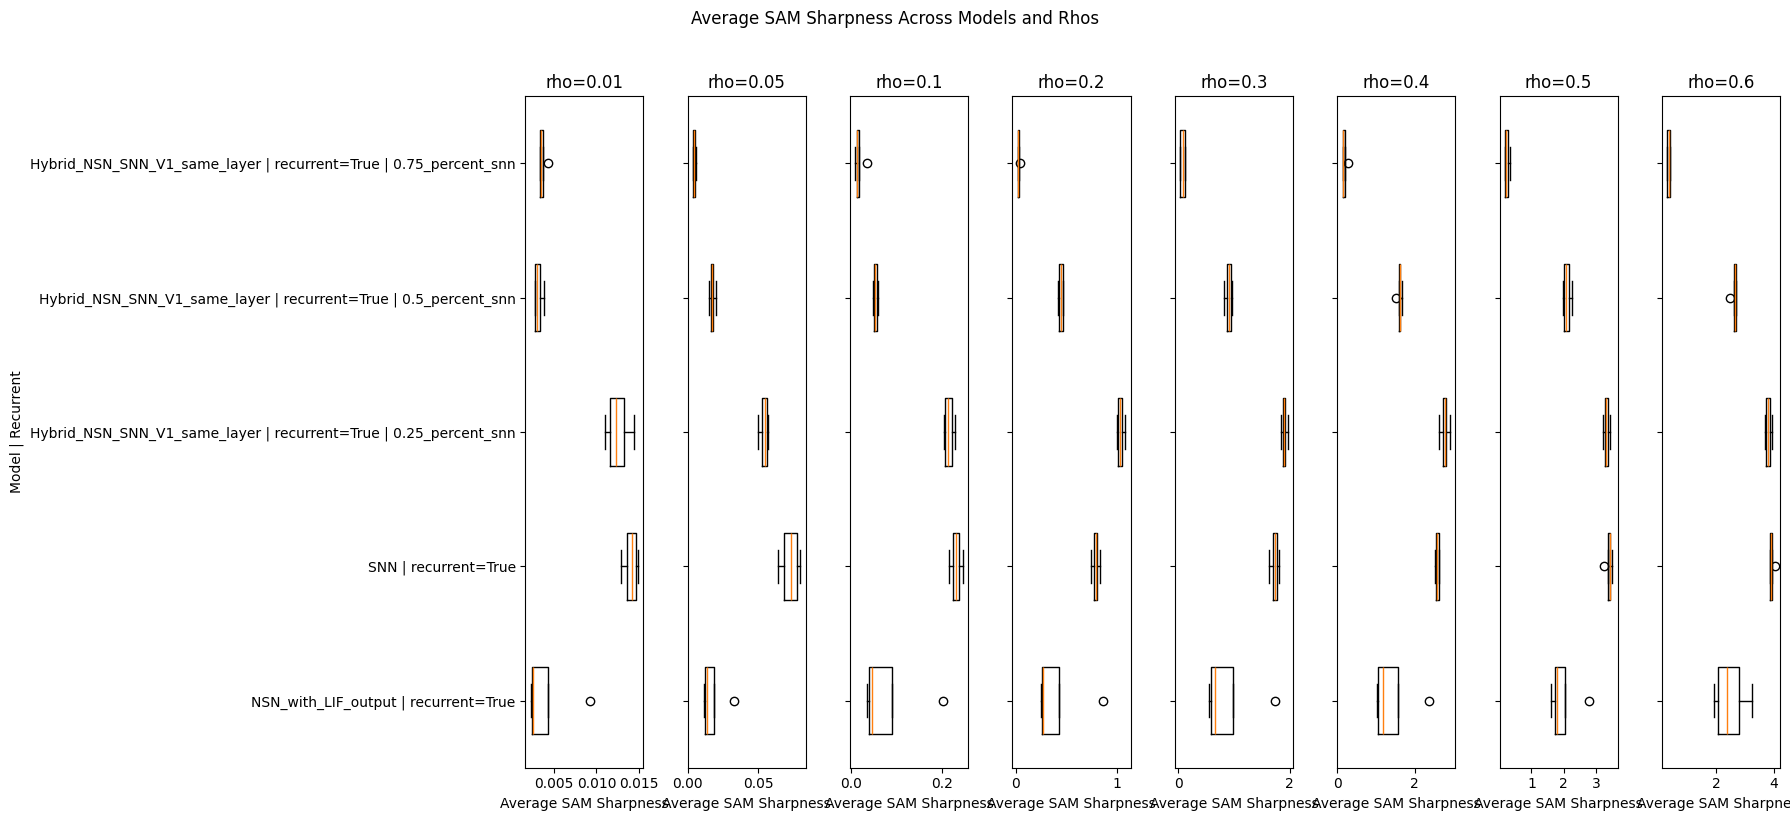

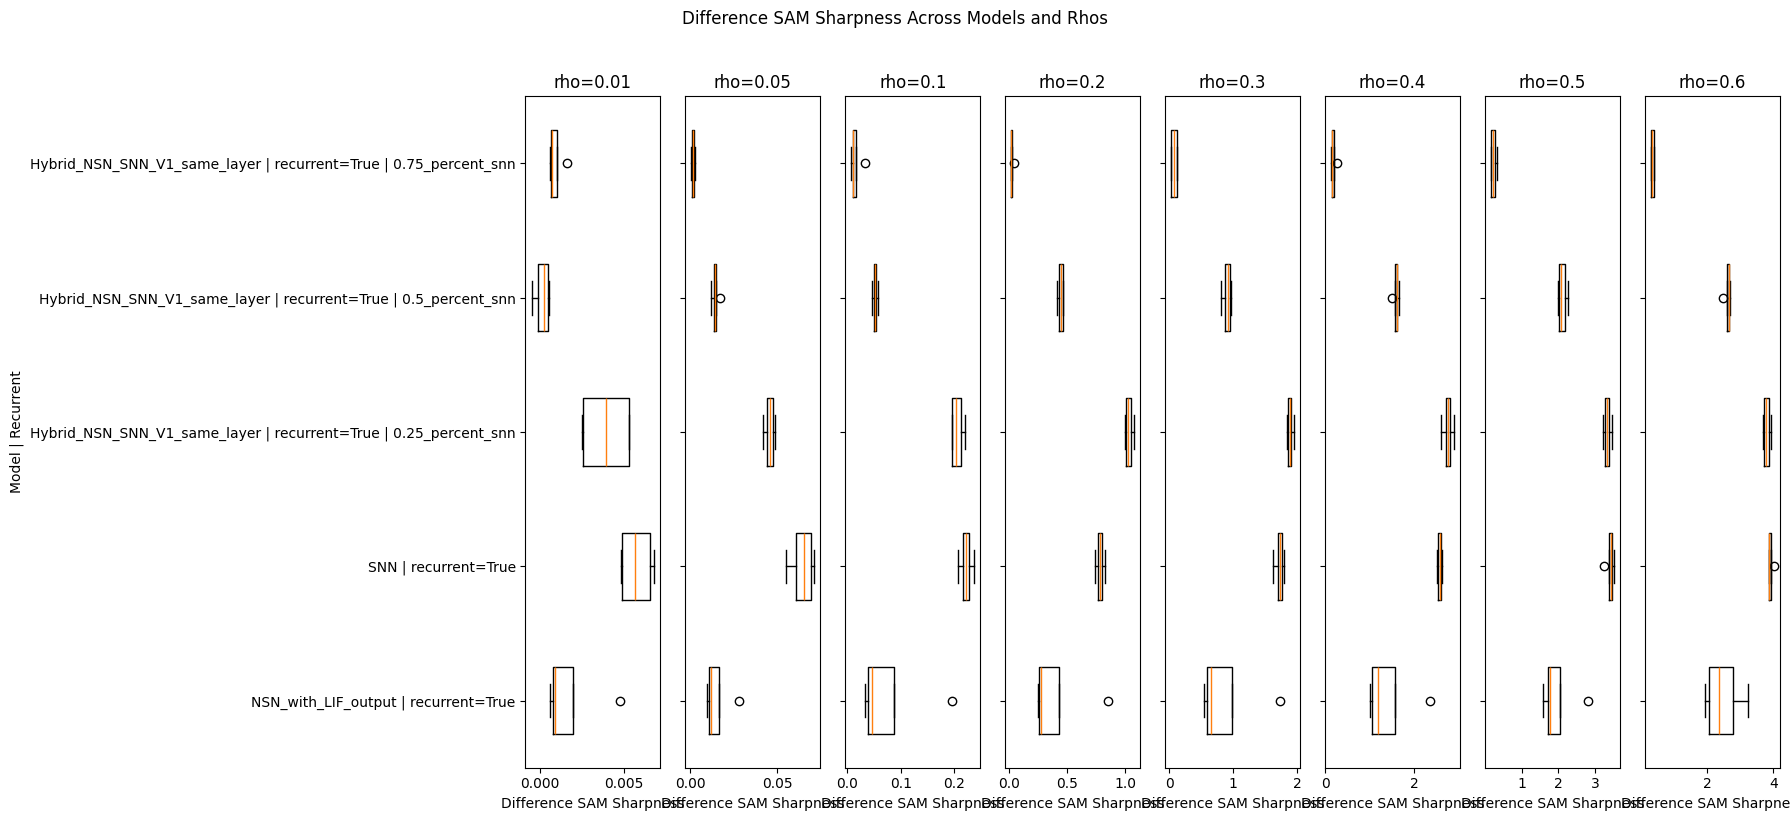

In [ ]:
plot_sam_results(rho_list, sam_results, labels)

# Rerunning with flexible spiking conditional

In [ ]:
def conversion_df(sam_results, rho_list, labels):
    data = []
    for model_idx, label in enumerate(labels):
        for rho in rho_list:
            avg_vals = sam_results['avg'][rho][model_idx]
            diff_vals = sam_results['diff'][rho][model_idx]
            train_accuracy = sam_results['train_acc'][rho][model_idx]
            test_accuracy = sam_results['test_acc'][rho][model_idx]
            for avg, diff in zip(avg_vals, diff_vals):
                data.append({
                    'model': label,
                    'rho': rho,
                    'avg_sam': avg,
                    'diff_sam': diff,
                    'train_accuracy': train_accuracy,
                    'test_accuracy': test_accuracy
                })
    return pd.DataFrame(data)

df_final = conversion_df(sam_results, rho_list, labels)

In [ ]:
df_final

,model,rho,avg_sam,diff_sam,train_accuracy,test_accuracy
0,NSN_with_LIF_output | recurrent=True,0.01,0.009280,0.004740,1.0,1.0
1,NSN_with_LIF_output | recurrent=True,0.01,0.002621,0.001024,1.0,1.0
2,NSN_with_LIF_output | recurrent=True,0.01,0.002259,0.000623,1.0,1.0
3,NSN_with_LIF_output | recurrent=True,0.01,0.002499,0.000834,1.0,1.0
4,NSN_with_LIF_output | recurrent=True,0.05,0.032515,0.028240,1.0,1.0
...,...,...,...,...,...,...
155,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.50,0.179056,0.175738,1.0,1.0
156,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.60,0.312174,0.309210,1.0,1.0
157,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.60,0.311491,0.309251,1.0,1.0
158,Hybrid_NSN_SNN_V1_same_layer | recurrent=True ...,0.60,0.393834,0.391081,1.0,1.0


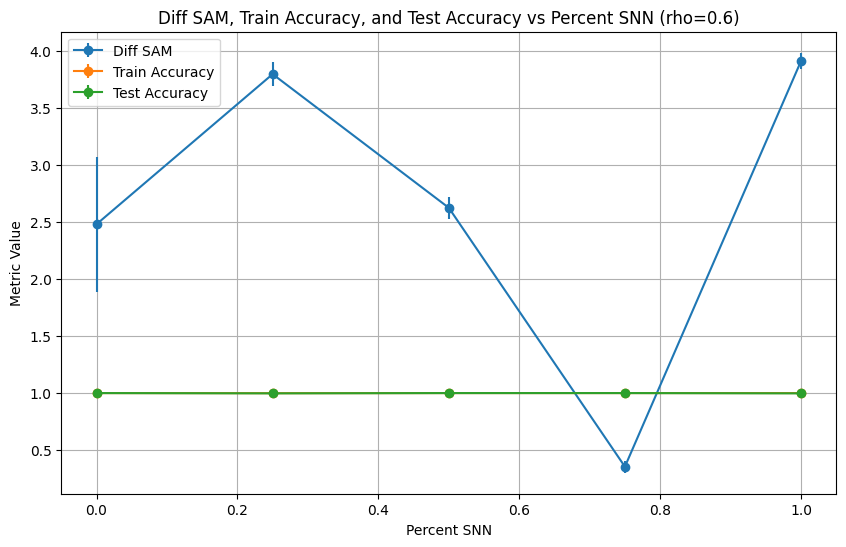

In [ ]:
# We'll filter df_final to only include "NSN_with_LIF_output", "Hybrid_NSN_SNN_V1_same_layer", and "SNN"
# Then assign percent_snn based on the model string
models_of_interest = ["NSN_with_LIF_output", "Hybrid_NSN_SNN_V1_same_layer", "SNN"]
filtered_rows = []
for _, row in df_final.iterrows():
    for model in models_of_interest:
        # For SNN, make sure there's no hybrid in the name
        if model == "SNN" and "Hybrid" in row['model']:
            continue
        if model in row['model']:
            # print(row['model'], model)
            new_row = row.to_dict()
            if "Hybrid" in model:
                if "0.25" in row['model']:
                    new_row['percent_snn'] = 0.25
                elif "0.5" in row['model']:
                    new_row['percent_snn'] = 0.5
                elif "0.75" in row['model']:
                    new_row['percent_snn'] = 0.75
                else:
                    new_row['percent_snn'] = None
            elif model == "SNN":
                new_row['percent_snn'] = 1
            elif model == "NSN_with_LIF_output":
                new_row['percent_snn'] = 0
            filtered_rows.append(new_row)
            break


# Filter to rho of 0.6, calculate averages and stds for each pct_snn (diff and train/validation accuracy). Then plot each as a line on graph, with x-axis as percent_snn and y-axis as diff_sam, train_accuracy, test_accuracy
df_rho_06 = pd.DataFrame(filtered_rows)
df_rho_06 = df_rho_06[df_rho_06['rho'] == 0.6]
df_rho_06 = df_rho_06[df_rho_06['percent_snn'].notnull()]

# Calculate averages and stddev for each percent_snn
summary_stats = df_rho_06.groupby('percent_snn').agg({
    'diff_sam': ['mean', 'std'],
    'train_accuracy': ['mean', 'std'],
    'test_accuracy': ['mean', 'std']
}).reset_index()
summary_stats.columns = ['percent_snn', 'diff_sam_mean', 'diff_sam_std', 'train_accuracy_mean', 'train_accuracy_std', 'test_accuracy_mean', 'test_accuracy_std']
# Plot these all on the same graph as lines with error bars, x-axis is percent_snn, y-axis is the metric
plt.figure(figsize=(10, 6))
plt.errorbar(summary_stats['percent_snn'], summary_stats['diff_sam_mean'], yerr=summary_stats['diff_sam_std'], label='Diff SAM', marker='o')
plt.errorbar(summary_stats['percent_snn'], summary_stats['train_accuracy_mean'], yerr=summary_stats['train_accuracy_std'], label='Train Accuracy', marker='o')
plt.errorbar(summary_stats['percent_snn'], summary_stats['test_accuracy_mean'], yerr=summary_stats['test_accuracy_std'], label='Test Accuracy', marker='o')
plt.xlabel('Percent SNN')
plt.ylabel('Metric Value')
plt.title('Diff SAM, Train Accuracy, and Test Accuracy vs Percent SNN (rho=0.6)')
plt.legend()
plt.grid(True)
plt.show()

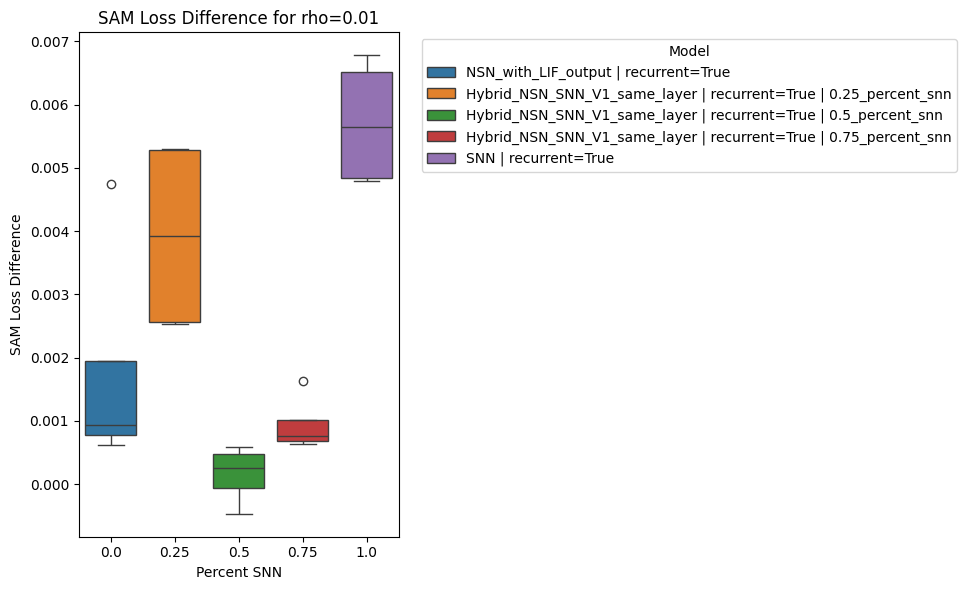

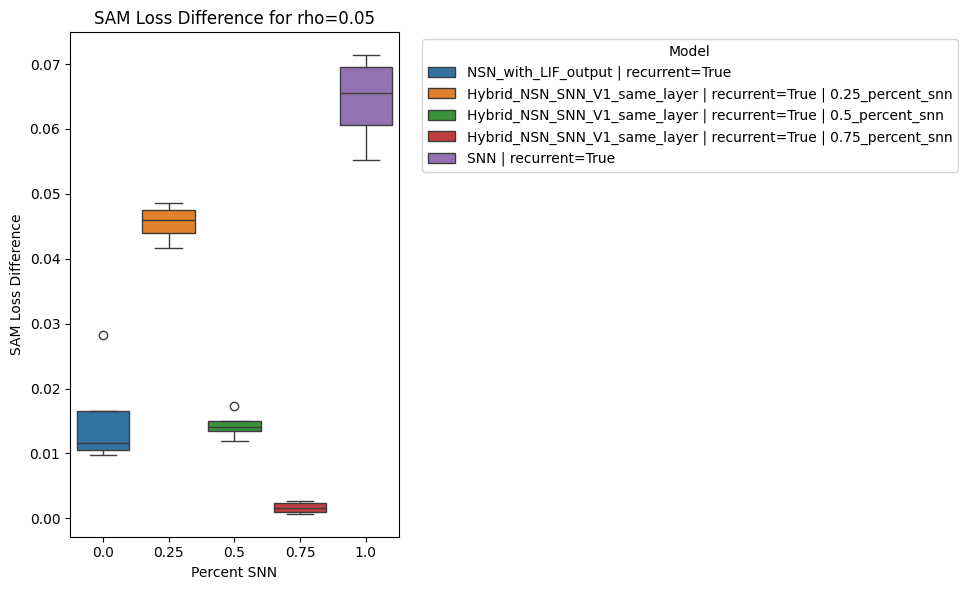

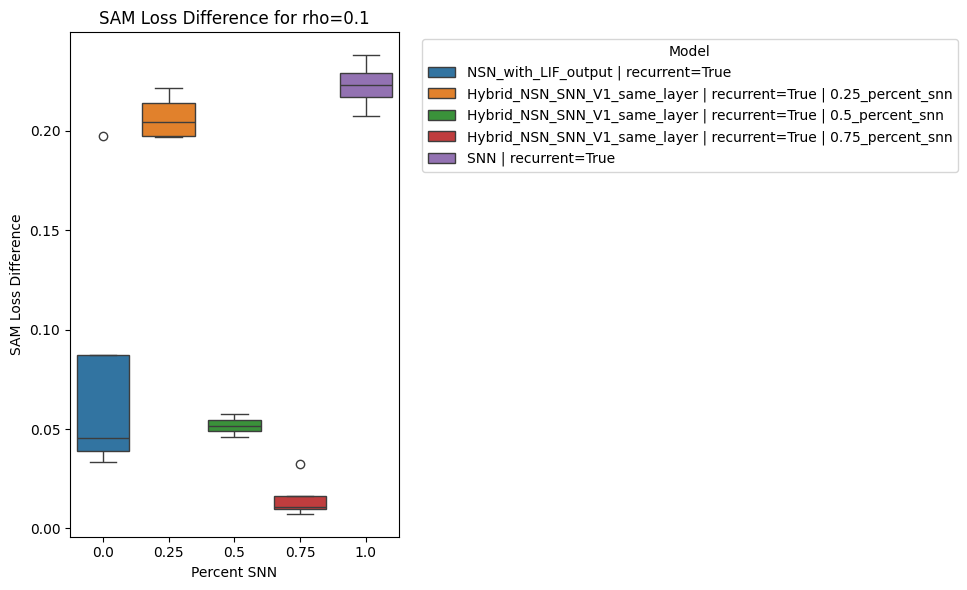

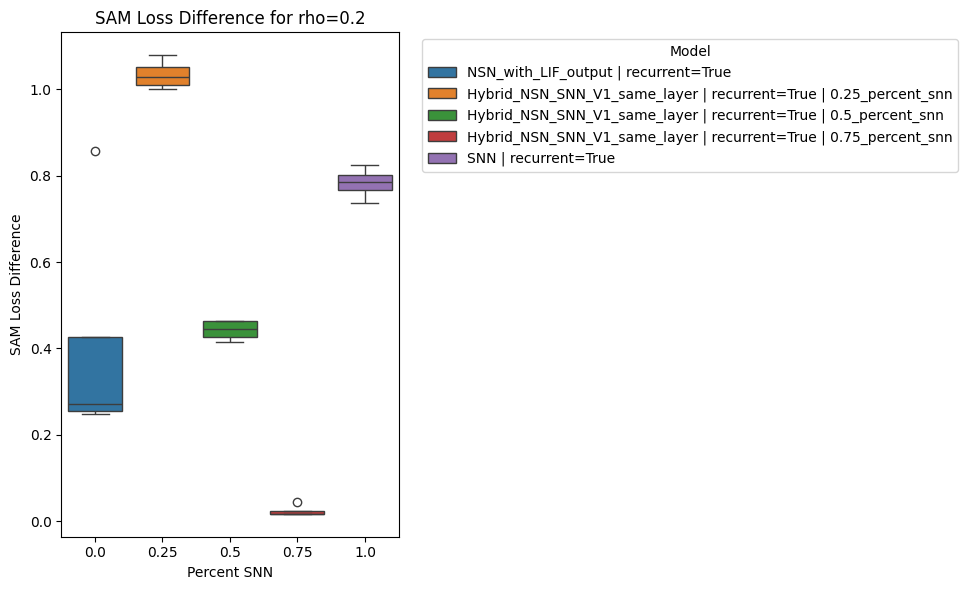

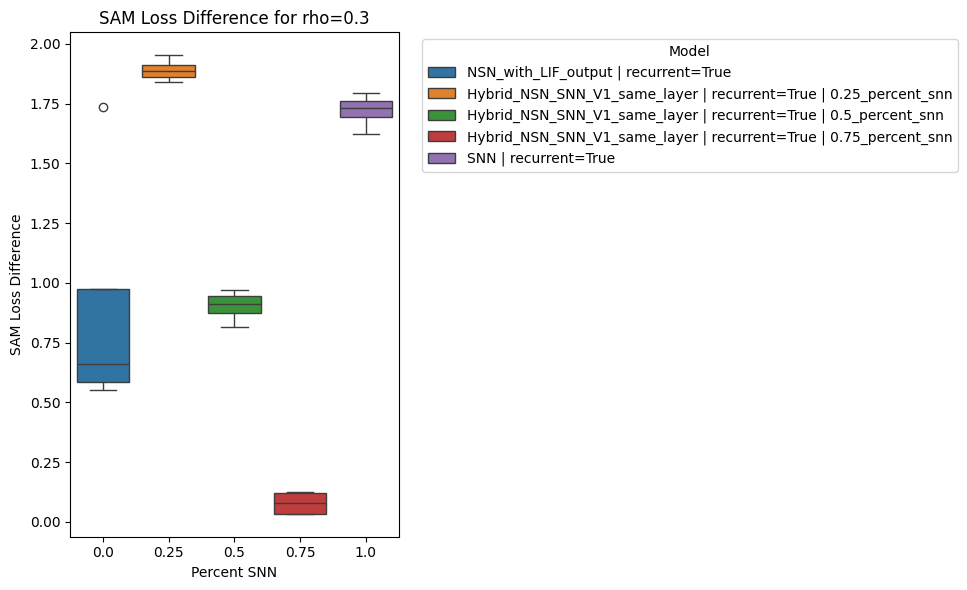

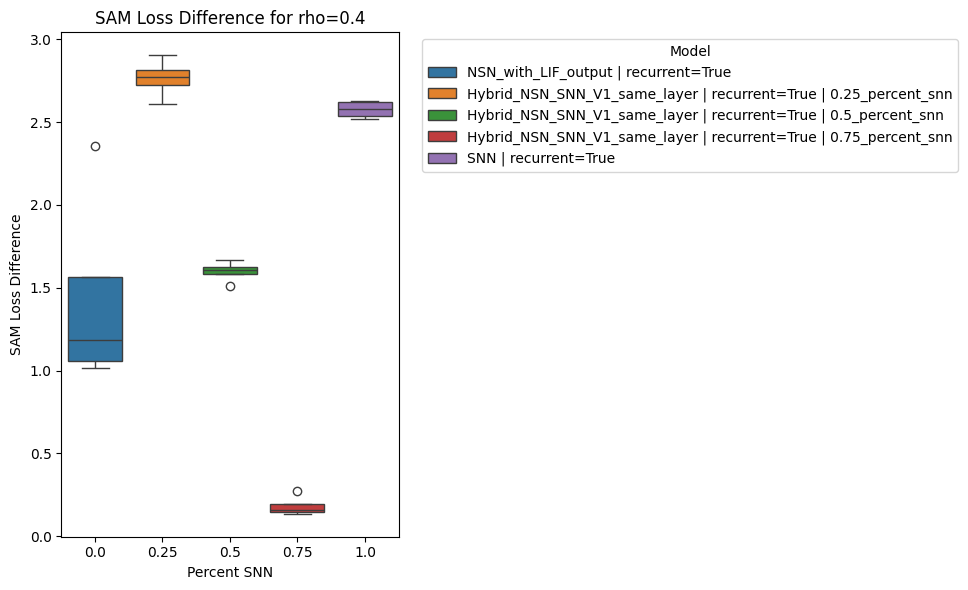

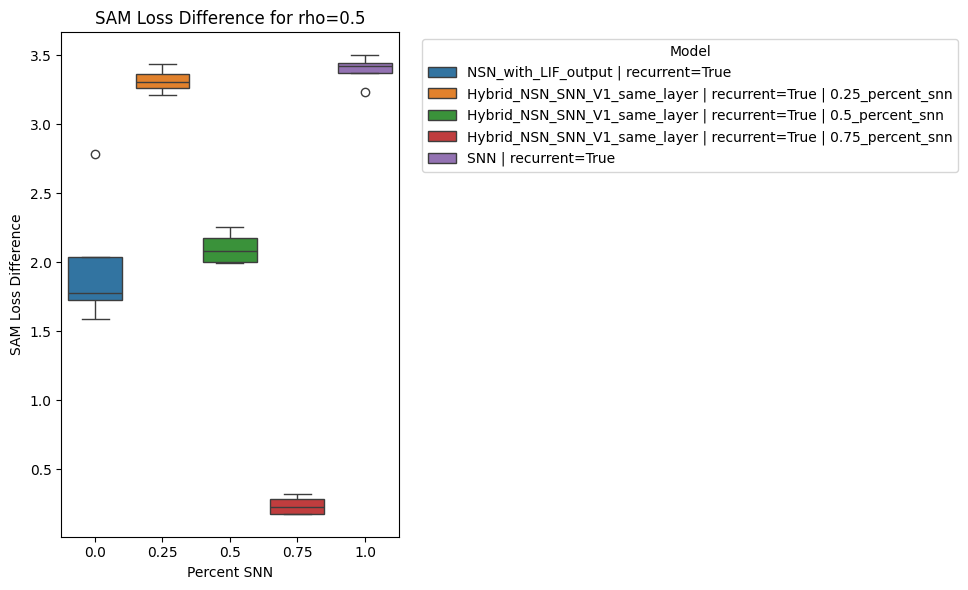

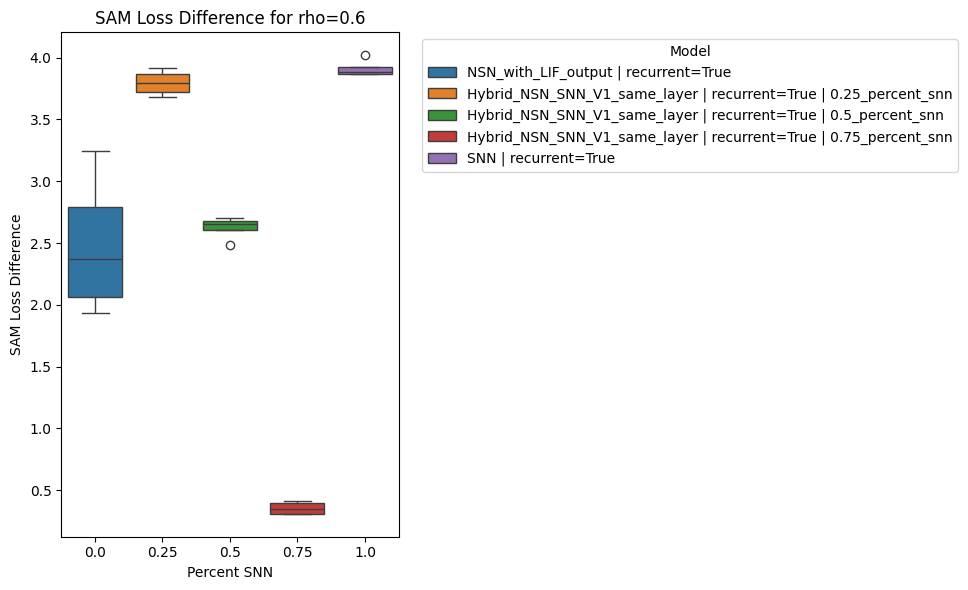

In [ ]:
import seaborn as sns
for rho in rho_list:
    plt.figure(figsize=(10, 6))
    df_rho = pd.DataFrame([row for row in filtered_rows if row['rho'] == rho])
    sns.boxplot(data=df_rho, x='percent_snn', y='diff_sam', hue='model')
    plt.title(f"SAM Loss Difference for rho={rho}")
    plt.xlabel("Percent SNN")
    plt.ylabel("SAM Loss Difference")
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# Take the accuracy and plot it separately. For the same set of models


In [ ]:
# calculate_and_visualize_sam("shd")

In [ ]:
# # --- Helpers for flattening / unflattening ---
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# from sklearn.decomposition import PCA
# import sys

# sys.path.append("/scratch/nar8991/snn/snn_ann_hybrid")

# from class_based_implementation.models import SNN, ANN_with_LIF_output, Hybrid_RNN_SNN_rec, Hybrid_RNN_SNN_V1_same_layer, NSN_with_LIF_output, Hybrid_NSN_SNN_rec, Hybrid_NSN_SNN_V1_same_layer
# from class_based_implementation.surr_grad import SurrGradSpike
# from loss_landscapes.utils import get_shd_train_data, get_randman_data


# def _flatten_params(params):
#     vecs = [p.detach().reshape(-1) for p in params]
#     shapes = [p.shape for p in params]
#     return torch.cat(vecs), shapes

# def _unflatten_params(vec, shapes):
#     tensors = []
#     idx = 0
#     for shape in shapes:
#         numel = np.prod(shape)
#         tensors.append(vec[idx:idx+numel].reshape(shape))
#         idx += numel
#     return tensors

# def _assign_flat_params(params, flat_vec, shapes, device=None):
#     tensors = _unflatten_params(flat_vec, shapes)
#     for p, t in zip(params, tensors):
#         t = t.to(p.device if device is None else device)
#         p.data.copy_(t)

# # --- Compute PCA directions across multiple models ---
# def compute_shared_pca(models, device="cuda"):
#     flat_params_list = []

#     # models is now a list of model instances, not checkpoint paths
#     for model in models:
#         params = list(model.parameters())
#         flat_vec, _ = _flatten_params(params)
#         flat_params_list.append(flat_vec.cpu().numpy())  # PCA on CPU

#     flat_matrix = np.stack(flat_params_list)
#     pca = PCA(n_components=2)
#     pca.fit(flat_matrix)

#     d1 = torch.tensor(pca.components_[0], dtype=torch.float32, device=device)
#     d2 = torch.tensor(pca.components_[1], dtype=torch.float32, device=device)

#     # Per-tensor normalization
#     # shapes = [p.shape for p in list(models[0].parameters())]
#     # d1_tensors = _unflatten_params(d1, shapes)
#     # d2_tensors = _unflatten_params(d2, shapes)
#     # params = list(models[0].parameters())
#     # for W, D1, D2 in zip(params, d1_tensors, d2_tensors):
#     #     D1 *= W.norm() / (D1.norm() + 1e-12)
#     #     D2 *= W.norm() / (D2.norm() + 1e-12)
#     # d1_normed = torch.cat([t.reshape(-1) for t in d1_tensors])
#     # d2_normed = torch.cat([t.reshape(-1) for t in d2_tensors])

#     return d1.to(device), d2.to(device)

# # --- Visualize loss landscape ---
# def visualize_loss_landscape(model, dataloader, d1, d2,
#                              criterion=torch.nn.CrossEntropyLoss(),
#                              device="cuda",
#                              resolution=21,
#                              range_lim=1.0,
#                              save_prefix=None):
#     """
#     Visualizes the 2D loss landscape around a model's parameters.
    
#     Args:
#         mode
#         l (torch.nn.Module): The base model instance.
#         dataloader (torch.utils.data.DataLoader): Data for evaluating the loss.
#         d1 (torch.Tensor): The first direction vector (e.g., from PCA).
#         d2 (torch.Tensor): The second direction vector.
#         criterion (callable): The loss function.
#         device (str): The device for computation.
#         resolution (int): The number of points to sample along each axis.
#         range_lim (float): The range of movement along each direction (-range_lim to +range_lim).
#         save_prefix (str): Prefix for saving the plots. If None, plots are not saved.
#     """
#     model.to(device).eval()
#     params = list(model.parameters())
#     base_vec, shapes = _flatten_params(params)
#     base_vec = base_vec.to(device)
    
#     # Build grid
#     alphas = np.linspace(-range_lim, range_lim, resolution)
#     betas = np.linspace(-range_lim, range_lim, resolution)
#     loss_grid = np.zeros((resolution, resolution), dtype=np.float32)

#     for i, a in enumerate(tqdm(alphas, desc="α")):
#         for j, b in enumerate(betas):
#             offset = (a * d1 + b * d2).to(device)
#             _assign_flat_params(params, base_vec + offset, shapes, device=device)
            
#             total_loss = 0.0
#             total_count = 0
#             for xb, yb in dataloader:
#                 xb, yb = xb.to(device), yb.to(device)
#                 outputs = model(xb)
#                 # if outputs is tuple, extract predictions
#                 if isinstance(outputs, tuple):
#                     outputs = outputs[0]
#                 # for recurrent outputs, take max over time dimension if needed
#                 if outputs.dim() > 2:
#                     outputs, _ = torch.max(outputs, dim=1)
#                 loss = criterion(outputs, yb)
#                 total_loss += loss.item() * xb.size(0)
#                 total_count += xb.size(0)
#             loss_grid[j, i] = total_loss / total_count

#     # Restore original params
#     _assign_flat_params(params, base_vec, shapes, device=device)

#     # 3D surface plot
#     A, B = np.meshgrid(alphas, betas)
#     fig3d = plt.figure(figsize=(6,5))
#     ax3d = fig3d.add_subplot(111, projection="3d")
#     surf = ax3d.plot_surface(A, B, loss_grid, cmap="viridis", edgecolor="none", alpha=0.9)
#     ax3d.set_xlabel("α")
#     ax3d.set_ylabel("β")
#     ax3d.set_zlabel("Loss")
#     ax3d.set_title(f"{save_prefix} - 3D Loss Surface")
#     fig3d.colorbar(surf, shrink=0.6, aspect=10, label="Loss")
#     if save_prefix: fig3d.savefig(f"{save_prefix}_3d.png", dpi=300, bbox_inches="tight")
#     fig3d.show()
#     # 2D contour plot (with lines)
#     fig2d, ax2d = plt.subplots(figsize=(5,4))
#     cs = ax2d.contour(alphas, betas, loss_grid, levels=30, cmap="viridis")
#     fig2d.colorbar(cs, ax=ax2d, label="Loss")
#     ax2d.set_xlabel("α")
#     ax2d.set_ylabel("β")
#     ax2d.set_title("2D Loss Contour")
#     if save_prefix: fig2d.savefig(f"{save_prefix}_2d.png", dpi=300, bbox_inches="tight")
#     fig2d.show()
#     return fig3d, fig2d

In [ ]:
# # -------------------------------
# # Main loop (simplified, no rho)
# # -------------------------------
# BASE_PATH="/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/randman/1_d/2_classes/3/cross_entropy"

# MODEL_CLASSES = {
#     "NSN_with_LIF_output": NSN_with_LIF_output,
#     "SNN": SNN,
#     "ANN_with_LIF_output": ANN_with_LIF_output,
#     "Hybrid_RNN_SNN_rec": Hybrid_RNN_SNN_rec,
#     "Hybrid_NSN_SNN_rec": Hybrid_NSN_SNN_rec,
#     "Hybrid_RNN_SNN_V1_same_layer": Hybrid_RNN_SNN_V1_same_layer,
#     "Hybrid_NSN_SNN_V1_same_layer": Hybrid_NSN_SNN_V1_same_layer,
# }

# # Load all models first to compute PCA directions
# all_models = []
# for model_name, model_class in MODEL_CLASSES.items():
#     percent_list = [0.25, 0.5, 0.75] if 'Hybrid' in model_name else [None]
#     for percent in percent_list:
#         for seed in range(1, 5):
#             base_path = f"{BASE_PATH}/{model_name}/recurrent_True/seed_{seed}/grid_sampler/20_hidden/1.0_pct_data"
#             model_path_suffix = f"{percent}_percent_snn/best_model_of_study.ckpt" if percent else "best_model_of_study.ckpt"
#             model_file_path = f"{base_path}/{model_path_suffix}"
#             model = model_class.load_from_checkpoint(model_file_path)
#             all_models.append(model)

# # Compute shared PCA directions
# d1, d2 = compute_shared_pca(all_models)
# train_loader = get_randman_data()

# # Loop again to visualize
# for model_name, model_class in MODEL_CLASSES.items():
#     for recurrent in ["True"]:
#         percent_list = [0.25, 0.5, 0.75] if 'Hybrid' in model_name else [None]
#         for percent in percent_list:
#             for seed in range(1,5):
#                 base_path = f"{BASE_PATH}/{model_name}/recurrent_{recurrent}/seed_{seed}/grid_sampler/20_hidden/1.0_pct_data"
#                 model_path_suffix = f"{percent}_percent_snn/best_model_of_study.ckpt" if percent else "best_model_of_study.ckpt"
#                 model_file_path = f"{base_path}/{model_path_suffix}"
#                 model = model_class.load_from_checkpoint(model_file_path)
                
#                 # Visualize loss landscape along shared PCA directions
#                 visualize_loss_landscape(model, train_loader, d1, d2,
#                                          criterion=torch.nn.CrossEntropyLoss(),
#                                          device="cuda", resolution=21, range_lim=1,
#                                          save_prefix=f"{model_name}_seed{seed}_{percent}")


In [ ]:
# import os

# for filename in os.listdir(img_dir):
#     if filename.endswith(".png"):
#         if not ("None" in filename or "0.25" in filename or "0.5" in filename or "0.75" in filename):
#             os.remove(os.path.join(img_dir, filename))


In [ ]:
# import os
# from PIL import Image, UnidentifiedImageError
# from collections import defaultdict
# img_dir = "/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/shd/None_d/20_classes/700/cross_entropy"
# # img_dir = "/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/randman/1_d/2_classes/3/cross_entropy"
# png_files = [f for f in os.listdir(img_dir) if f.endswith(".png") and "V1" in f and "combined" not in f]
# png_files.sort()

# # Group files by model type (prefix before '_seed')
# model_groups = defaultdict(list)
# for f in png_files:
#     if '_seed' in f:
#         prefix = f.split('_seed')[0]
#         model_groups[prefix].append(f)
#     else:
#         # If no seed, group by filename itself
#         model_groups[f].append(f)

# for model_type, files in model_groups.items():
#     images = []
#     widths, heights = [], []
#     for f in files:
#         try:
#             img_path = os.path.join(img_dir, f)
#             with Image.open(img_path) as img:
#                 images.append(img.copy())
#                 widths.append(img.size[0])
#                 heights.append(img.size[1])
#         except UnidentifiedImageError:
#             print(f"Skipping corrupted file: {f}")
#         except Exception as e:
#             print(f"An unexpected error occurred with file {f}: {e}")

#     if not images:
#         continue

#     max_width = max(widths)
#     max_height = max(heights)
#     cols = 5
#     rows = (len(images) + cols - 1) // cols

#     combined_img = Image.new("RGB", (cols * max_width, rows * max_height), color=(255, 255, 255))
#     for idx, img in enumerate(images):
#         x = (idx % cols) * max_width
#         y = (idx // cols) * max_height
#         combined_img.paste(img, (x, y))

#     combined_img.save(os.path.join(img_dir, f"{model_type}_combined.png"), compress_level=9)


In [ ]:
sam_results

{'avg': {0.01: [[0.009279892469445864,
    0.0026206255424767733,
    0.0022585963209470115,
    0.002499418333172798],
   [0.014902998693287373,
    0.013777279605468115,
    0.012858250799278418,
    0.014639217096070448],
   [0.01279534058024486,
    0.011057572594533363,
    0.011836785823106766,
    0.014425251943369707],
   [0.0027071815760185323,
    0.003222064425547918,
    0.003856438289706906,
    0.0028120558320855102],
   [0.0033942152125140033,
    0.003317292508048316,
    0.004322573775425553,
    0.0035593255888670683]],
  0.05: [[0.032515352591872215,
    0.014201505109667778,
    0.01243636291474104,
    0.011618821881711483],
   [0.07018333052595456,
    0.0765020673473676,
    0.06370031212766965,
    0.07991071914633115],
   [0.04952443018555641,
    0.053910836577415466,
    0.05664642155170441,
    0.055753692984580994],
   [0.01741958688944578,
    0.015065974555909634,
    0.016602904846270878,
    0.02015531187256177],
   [0.0037879908146957555,
    0.0061161

In [ ]:
# To do:
# Pull accuracies from the random manifold dataset and plot them again for our first figure
# Run 80%, etc. for the % spiking (figure out #s that make sense)
# This would be -> 
# Create more versions of SHD

